Separación entre esferas (S): 3e-08 metros


Output()

Output()

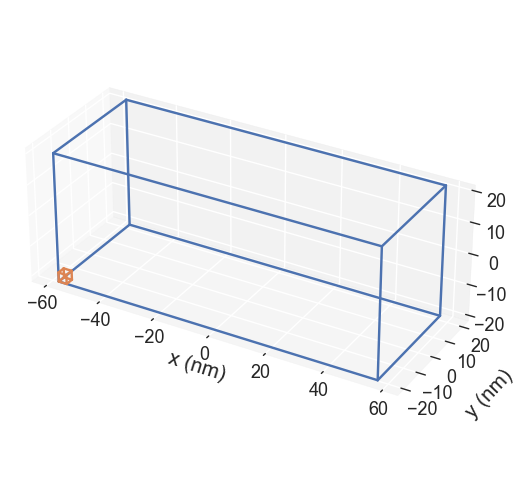

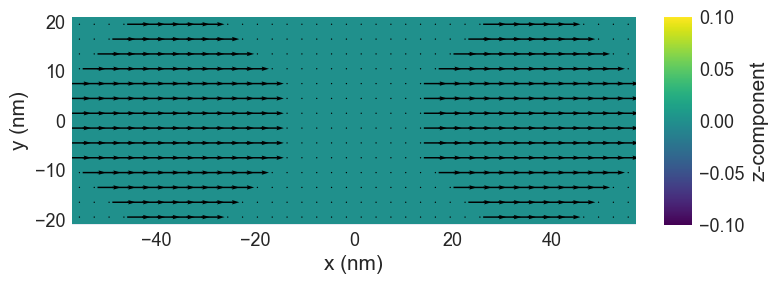

In [2]:
import micromagneticmodel as mm
import discretisedfield as df
import numpy as np
import matplotlib.pyplot as plt
import k3d
import oommfc as oc
import random

# Dimensiones del sistema
Lx = 114e-9  # Longitud total en x (para acomodar 2 esferas)
Ly = 42e-9   # Dimensión en y
Lz = 42e-9   # Dimensión en z
c = 3e-9     # Tamaño de celda

# Parámetros de las esferas
radius = 21e-9       # Radio de las esferas
radius_squared = radius**2
E_0 = 36e-9          # Distancia del borde de la esfera al origen

# Separación entre esferas (de borde a borde)
S = 2 * (E_0 - radius)
print(f"Separación entre esferas (S): {S} metros")

# Definición de región y malla
p1 = (-Lx / 2, -Ly / 2, -Lz / 2)
p2 = (Lx / 2, Ly / 2, Lz / 2)
cell = (c, c, c)

region = df.Region(p1=p1, p2=p2)
mesh = df.Mesh(region=region, cell=cell)

# Visualización básica de la malla
mesh.mpl()
mesh.k3d()

# Definición del sistema micromagnético
system = mm.System(name="ensayo4")
gamma0 = mm.consts.gamma0
alpha = 1
system.dynamics = mm.Precession(gamma0=gamma0) + mm.Damping(alpha=alpha)

# Parámetros del material
Ms = 1.7e6      # Magnetización de saturación (A/m)
K = 48e3        # Constante de anisotropía (J/m^3)
A = 2.1e-11     # Constante de intercambio (J/m)
H = (0 / mm.consts.mu0, 0, 0)  # Campo externo

# Ejes de anisotropía
u1 = (1, 0, 0)
u2 = (0, 1, 0)
u3 = (0, 0, 1)

# Función de magnetización de saturación (define las dos esferas)
def Ms_fun(point):
    x, y, z = point
    r1_squared = (x + E_0)**2 + y**2 + z**2
    r2_squared = (x - E_0)**2 + y**2 + z**2
    if r1_squared <= radius_squared or r2_squared <= radius_squared:
        return Ms
    else:
        return 0

# Energía total del sistema
system.energy = (
    mm.Exchange(A=A) +
    mm.CubicAnisotropy(K=K, u1=u1, u2=u2) +
    mm.Zeeman(H=H) +
    mm.Demag()
)

# Campo magnético inicial (uniforme en +x)
system.m = df.Field(mesh, nvdim=3, value=(1, 0, 0), norm=Ms_fun)

# Visualización 2D de la orientación en z
system.m.orientation.sel("z").mpl()

# Visualización 3D usando k3d
plot = k3d.plot()

# Dibujo de los contornos del dominio
for z in np.linspace(p1[2], p2[2], 10):
    plot += k3d.line(
        [
            [p1[0], p1[1], z],
            [p2[0], p1[1], z],
            [p2[0], p2[1], z],
            [p1[0], p2[1], z],
            [p1[0], p1[1], z],
        ],
        shader="flat",
        color=0x0000ff,
    )

# Dibujo de los puntos que representan las esferas
points = []
for x in np.linspace(p1[0], p2[0], 40):
    for y in np.linspace(p1[1], p2[1], 40):
        for z in np.linspace(p1[2], p2[2], 40):
            if Ms_fun((x, y, z)) > 0:
                points.append([x, y, z])

plot += k3d.points(points, point_size=0.3, color=0xff0000)
plot.display()


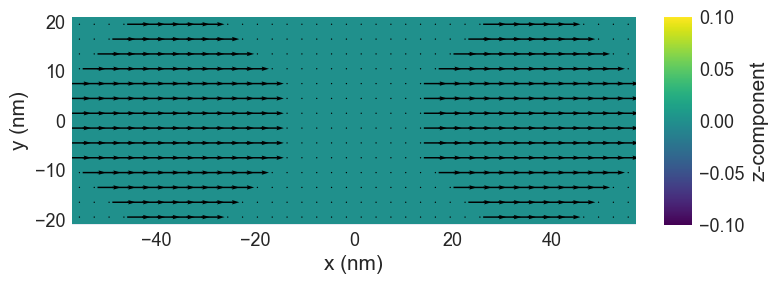

In [3]:
system.m.sel('z').mpl()


In [4]:
radius_squared

4.4099999999999997e-16

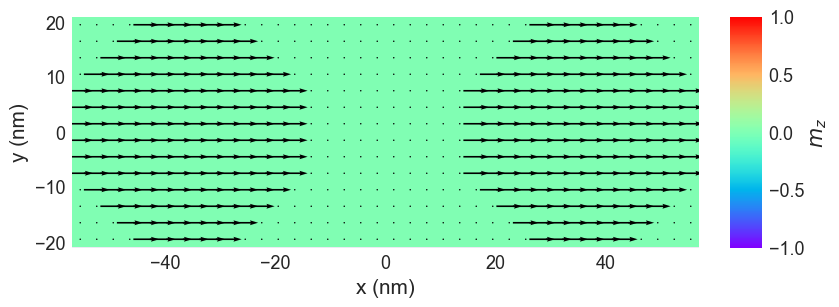

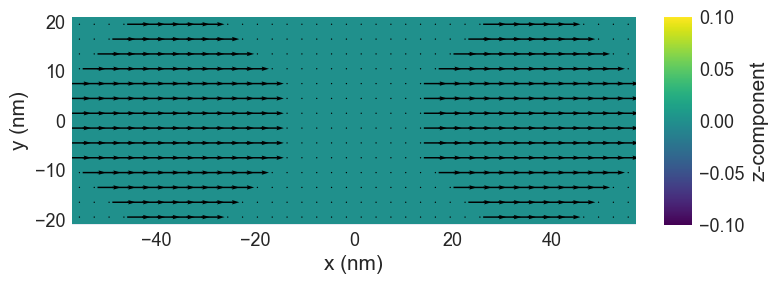

In [5]:
system.m.sel('z').mpl(figsize=(10, 3), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'})
system.m.orientation.sel('z').mpl()

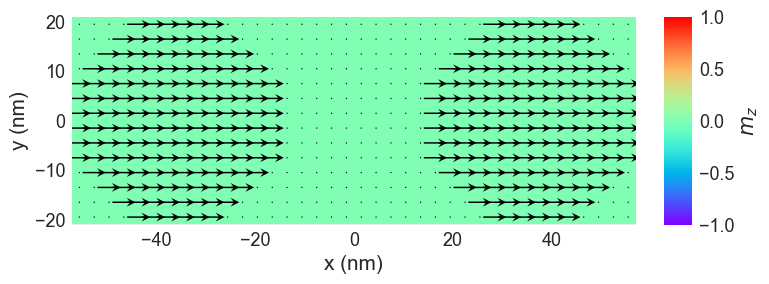

In [6]:
system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': None, 'headwidth': 6, 'headlength': 6, 'headaxislength': 4}); plt.savefig('ajuste_vectores.png')
###

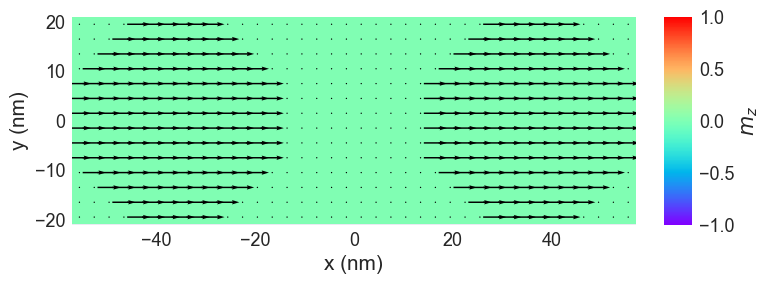

In [23]:
system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1})

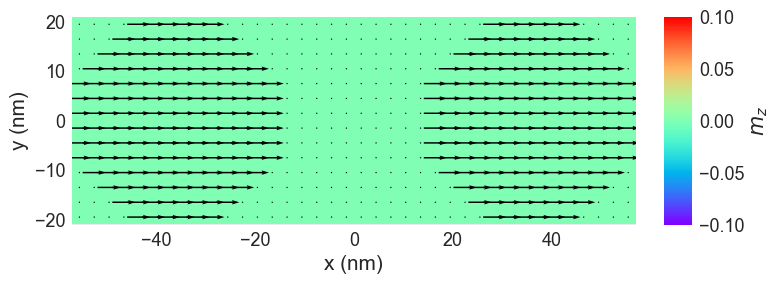

In [8]:
system.m.orientation.sel('z').mpl(scalar_kw={'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1})

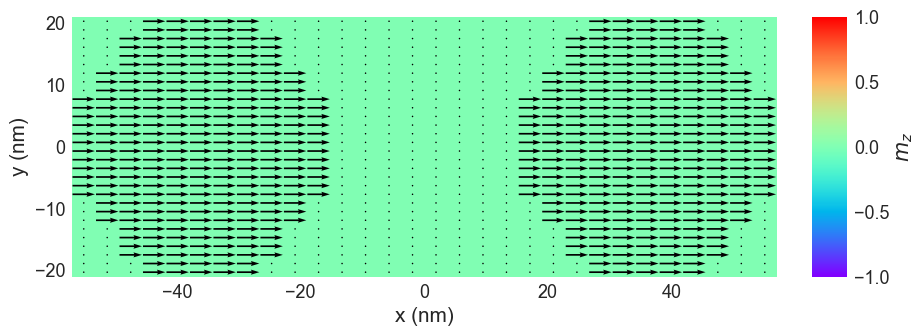

In [9]:
system.m.orientation.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}); plt.savefig('485')
        

In [24]:
# Primera gráfica y guardado
system.m.orientation.sel('z').mpl(
    scalar_kw={
        'clim': [-1, 1], 
        'colorbar_label': '$m_z$', 
        'cmap': 'rainbow', 
        'alpha': 1
    }, 
    vector_kw={
        'scale': None, 
        'headwidth': 6, 
        'headlength': 6, 
        'headaxislength': 4
    }
)
plt.savefig('500_1.png')
plt.close()  # Cierra la figura para liberar memoria

# Segunda gráfica en nueva figura y guardado
plt.figure()
system.m.orientation.sel('z').mpl(
    scalar_kw={
        'clim': [-1, 1], 
        'colorbar_label': '$m_z$', 
        'cmap': 'rainbow', 
        'alpha': 1
    }, 
    vector_kw={
        'scale': None, 
        'headwidth': 6, 
        'headlength': 6, 
        'headaxislength': 4
    }
)
plt.savefig('500_2.png')
plt.close()


<Figure size 800x600 with 0 Axes>

In [12]:
mesh.k3d()

Output()

Output()

Output()

Output()

Output()

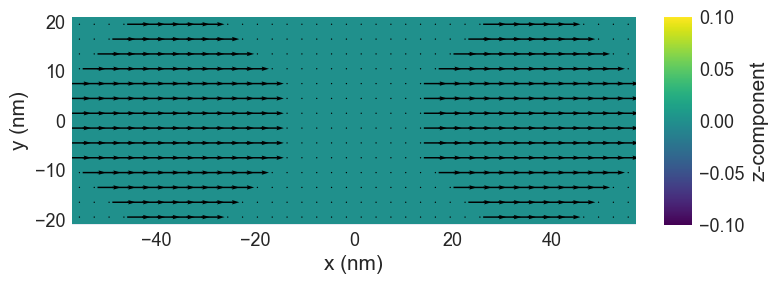

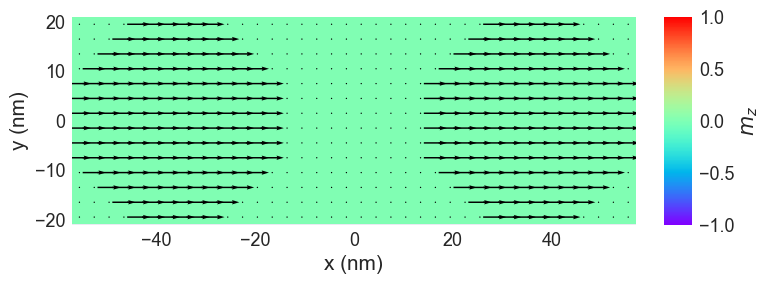

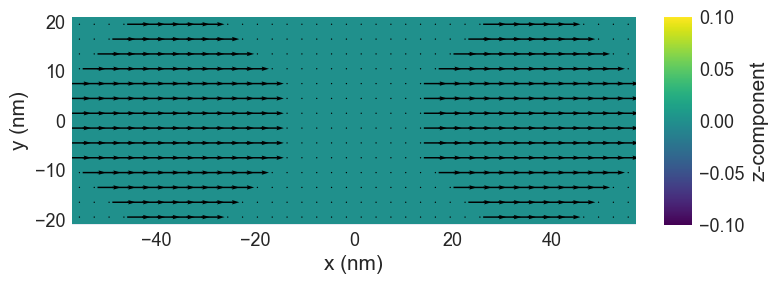

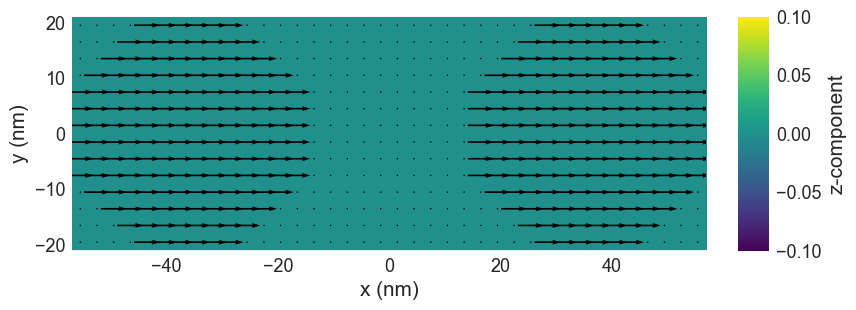

In [13]:
#RESULTING GRAPHICS taken from beta, original, final original 
system.m.orientation.sel("z").mpl()
system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1})
system.m.sel('z').mpl()
system.m.sel('z').mpl(figsize=(9, 7))
system.m.norm.k3d.nonzero()
system.m.k3d.vector(head_size=5)
system.m.k3d.vector()
system.m.k3d.vector(color_field=system.m.x)

In [25]:

md = oc.MinDriver()
md.drive(system)

fig = system.m.orientation.sel('z').mpl(
    scalar_kw={
        'clim': [-1, 1],
        'colorbar_label': '$m_z$',
        'cmap': 'rainbow',
        'alpha': 1
    },
    vector_kw={
        'scale': None,
        'headwidth': 5,
        'headlength': 5,
        'headaxislength': 5
    }
)

plt.savefig('N165.png')
plt.close(fig)  # Cierra la figura para liberar memoria


Docker was not found.


OSError: Cannot find OOMMF.

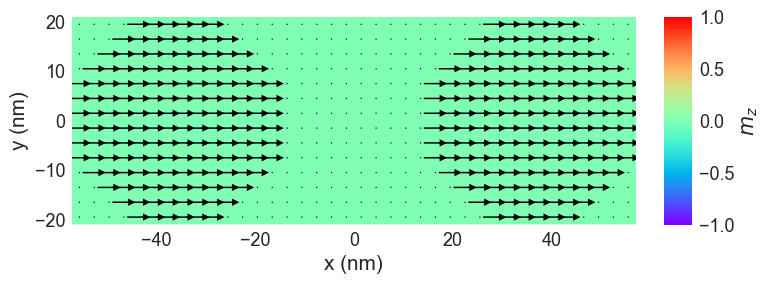

In [15]:


system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': None, 'headwidth': 5, 'headlength': 5, 'headaxislength': 5}); plt.savefig('N165')
      #xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx  #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N160')

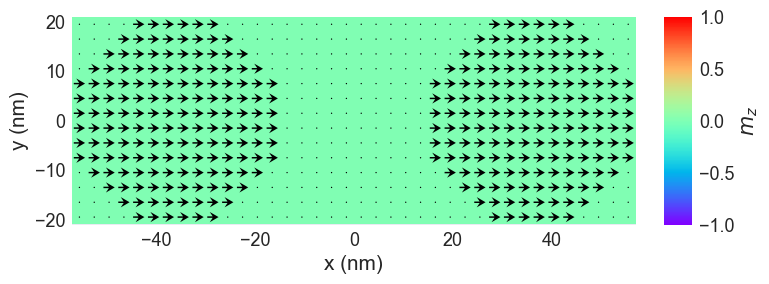

In [16]:
system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N165')
      #xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx  #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N160')

In [17]:
td = oc.TimeDriver()
td.drive(system, t=5e-9, n=10)

Running OOMMF (ExeOOMMFRunner)[2025/04/11 16:20]... (5.6 s)


IndexError: list index out of range

In [27]:
import micromagneticmodel as mm
import discretisedfield as df
import oommfc as oc

# Asumiendo que ya tienes definido el mesh y system...

# Minimización previa
md = oc.MinDriver()
md.drive(system)

# Ahora simula la dinámica de tiempo
td = oc.TimeDriver()
td.drive(system, t=5e-9, n=10)  # 5 ns en 10 pasos


Docker was not found.


OSError: Cannot find OOMMF.

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt

B1_array = np.arange(0.40, -0.40, -0.010) #decreasing field branch in Teslas
B2_array = np.arange(-0.40, 0.40, 0.010) #increasing field branch in Teslas

mg1 = [] #magnetization
fd1 = [] #applied field
ez1 = [] #Zeeman energy
ek1 = [] #Anisotropy energy
ex1 = [] #Exchange energy
ed1 = [] #Demagnetizing energy
tp1 = [] #Topological charge
for B in B1_array:
    H = (B/mm.consts.mu0, 0, 0)  # external magnetic field (A/m) in the x-direction
    system.energy = (mm.Exchange(A=A)
               + mm.CubicAnisotropy(K=K, u1=u1, u2=u2)
               + mm.Demag()
               + mm.Zeeman(H=H)) # energy of the system before relaxation
    # system relaxation at every single H value
    td.drive(system, t=5e-9, n=10)
    # Calcular la magnetización normalizada SOLO en las esferas
    Ms_total = np.sum(system.m.array * (system.m.norm.array > 0))  # Solo donde hay material
    V_esferas = np.sum(system.m.norm.array > 0) * system.m.mesh.cell[0]**3
    #V_esferas = 2 * (4/3) * np.pi * (21e-9)**3  # Volumen total de las dos esferas
    M_norm = Ms_total / (Ms * (V_esferas / (system.m.mesh.cell[0]**3)))  # Normalización correcta
    mg1.append(M_norm)  # Para la rama descendente

    #m_x = system.m.orientation.mean()[0]
    #mg1.append(m_x)
    fd1.append(H[0]*1e3*mm.consts.mu0)
    m = system.m.orientation
    Ez = sum(mm.consts.mu0 * Ms * m @ H for m in system.m) * system.m.mesh.region.volume
    Ek = sum(-K * (((m @ u1)**2) * ((m @ u2)**2) + ((m @ u2)**2) * ((m @ u3)**2) + ((m @ u3)**2) * ((m @ u1)**2)) for m in system.m) * system.m.mesh.region.volume
    Ex = oc.compute(system.energy.exchange.energy, system)
    Ed = oc.compute(system.energy.demag.energy, system)
    ez1.append(Ez)
    ek1.append(Ek)
    ex1.append(Ex)
    ed1.append(Ed)
    m1 = system.m.orientation.sel('z').array  # Ensure m1 is an array
    S = np.sum(m1 * (np.gradient(m1, axis=0) * np.gradient(m1, axis=1))) / (4 * math.pi)
    tp1.append(S)
    Hx = int(H[0]*1e3*mm.consts.mu0) #campo en miliTesla  


    

    if (495 <= Hx <= 499):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': None, 'headwidth': 6, 'headlength': 6, 'headaxislength': 4}); plt.savefig('500')
        #plt.figure(); system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': None, 'headwidth': 6, 'headlength': 6, 'headaxislength': 4}); plt.savefig('500')
        #system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 0.1, 'headwidth': 3, 'headlength': 4, 'headaxislength': 3}); plt.savefig('260')

    if (490 <= Hx <= 494):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': None, 'headwidth': 6, 'headlength': 6, 'headaxislength': 4}); plt.savefig('495')
        #system.m.orientation.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('490')
        

    if (485 <= Hx <= 489):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': None, 'headwidth': 6, 'headlength': 6, 'headaxislength': 4}); plt.savefig('490')
       # system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}); plt.savefig('485')
        
        #system.m.orientation.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('485')
        
        
    if (480 <= Hx <= 484):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': None, 'headwidth': 6, 'headlength': 6, 'headaxislength': 4}); plt.savefig('485')
         #system.m.orientation.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('480')
        
        
    if (475 <= Hx <= 479):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': None, 'headwidth': 6, 'headlength': 6, 'headaxislength': 4}); plt.savefig('480')
         #system.m.orientation.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('475')
        
        
    if (470 <= Hx <= 474):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': None, 'headwidth': 6, 'headlength': 6, 'headaxislength': 4}); plt.savefig('475')
         #system.m.orientation.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('470')
        

    if (465 <= Hx <= 469):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': None, 'headwidth': 6, 'headlength': 6, 'headaxislength': 4}); plt.savefig('470')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('465')
        
        
    if (460 <= Hx <= 464):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': None, 'headwidth': 6, 'headlength': 6, 'headaxislength': 4}); plt.savefig('465')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('460')
        

    if (455 <= Hx <= 459):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': None, 'headwidth': 6, 'headlength': 6, 'headaxislength': 4}); plt.savefig('460')
        #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('455')
        
        
    if (450 <= Hx <= 454):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': None, 'headwidth': 6, 'headlength': 6, 'headaxislength': 4}); plt.savefig('455')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('450')
        

    if (445 <= Hx <= 449):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': None, 'headwidth': 6, 'headlength': 6, 'headaxislength': 4}); plt.savefig('450')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('445')
        
        
    if (440 <= Hx <= 444):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': None, 'headwidth': 6, 'headlength': 6, 'headaxislength': 4}); plt.savefig('445')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('440')
        
        
    if (435 <= Hx <= 439):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': None, 'headwidth': 6, 'headlength': 6, 'headaxislength': 4}); plt.savefig('440')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('435')
        
        
    if (430 <= Hx <= 434):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': None, 'headwidth': 6, 'headlength': 6, 'headaxislength': 4}); plt.savefig('435')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('430')
        

    if (425 <= Hx <= 429):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': None, 'headwidth': 6, 'headlength': 6, 'headaxislength': 4}); plt.savefig('430')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('425')
        
    if (420 <= Hx <= 424):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': None, 'headwidth': 6, 'headlength': 6, 'headaxislength': 4}); plt.savefig('425')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('420')

    if (415 <= Hx <= 419):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': None, 'headwidth': 6, 'headlength': 6, 'headaxislength': 4}); plt.savefig('420')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('415')
        
    if (410 <= Hx <= 414):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': None, 'headwidth': 6, 'headlength': 6, 'headaxislength': 4}); plt.savefig('415')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('410')

    if (405 <= Hx <= 409):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': None, 'headwidth': 6, 'headlength': 6, 'headaxislength': 4}); plt.savefig('410')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('405')
        
    if (400 <= Hx <= 404):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('405')
        #system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}); plt.savefig('400')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('400')
        
    if (395 <= Hx <= 399):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('400')
        # system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('395')
        
    if (390 <= Hx <= 394):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('395')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('390')
       
    if (385 <= Hx <= 389):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('390')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('385')
        
    if (380 <= Hx <= 384):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('385')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(20, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('380')

    if (375 <= Hx <= 379):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('380')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('375')
        
    if (370 <= Hx <= 374):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('375')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('370')

    if (365 <= Hx <= 369):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('370')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('365')
        
    if (360 <= Hx <= 364):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('365')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('360')
     
    if (355 <= Hx <= 359):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('360')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('355')
        
    if (350 <= Hx <= 354):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('355')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('350')

    if (345 <= Hx <= 349):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('350')
        #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('345')
        
    if (340 <= Hx <= 344):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('345')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('340')

    if (335 <= Hx <= 339):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('340')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('335')
        
    if (330 <= Hx <= 334):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('335')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('330')

    if (325 <= Hx <= 329):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('330')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('325')
        
    if (320 <= Hx <= 324):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('325')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('320')
        
    if (315 <= Hx <= 319):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('320')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('315')
        
    if (310 <= Hx <= 314):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('315')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('310')

    if (305 <= Hx <= 309):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('310')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('305')
        
    if (300 <= Hx <= 304):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('305')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('300')
    
    ########################################################################################################################################
    #########################################################################################################################################   
    if (295 <= Hx <= 299):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('300')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('295')
        
    if (290 <= Hx <= 294):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('295')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('290')
        

    if (285 <= Hx <= 289):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('290')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('285')
        
        
    if (280 <= Hx <= 284):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('285')
        #system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}); plt.savefig('280')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('280')
        

    if (275 <= Hx <= 279):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('280')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('275')
        
        
    if (270 <= Hx <= 274):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('275')
        

    if (265 <= Hx <= 269):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('270')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('265')
        
    if (260 <= Hx <= 264):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('265')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('260')
        
        
    if (255 <= Hx <= 259):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('260')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('255')
        
        
    if (250 <= Hx <= 254):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('255')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('250')
        

    if (245 <= Hx <= 249):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('250')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('245')
        
    if (240 <= Hx <= 244):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('245')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('240')
        

    if (235 <= Hx <= 239):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('240')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('235')
        
        
    if (230 <= Hx <= 234):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('235')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('230')
        
    if (225 <= Hx <= 229):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('230')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('225')
        
        
    if (220 <= Hx <= 224):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('225')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('220')
        
        
    if (215 <= Hx <= 219):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('220')
        
    if (210 <= Hx <= 214):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('215')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('210')
        

    if (205 <= Hx <= 209):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('210')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('205')
        
        
    if (200 <= Hx <= 204):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('205')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('200')
        
    if (195 <= Hx <= 199):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('200')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('195')
        
        
    if (190 <= Hx <= 194):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('195')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('190')
        

    if (185 <= Hx <= 189):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('190')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('185')
        
        
    if (180 <= Hx <= 184):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('185')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('180')
        
        
    if (175 <= Hx <= 179):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('180')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('175')
        
        
    if (170 <= Hx <= 174):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('175')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('170')
        

    if (165 <= Hx <= 169):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('170')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('165')
        
        
    if (160 <= Hx <= 164):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('165')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('160')
        

    if (155 <= Hx <= 159):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('160')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('155')
        
        
    if (150 <= Hx <= 154):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('155')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('150')
        

    if (145 <= Hx <= 149):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('150')
        #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('145')
        
        
    if (140 <= Hx <= 144):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('145')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('140')
        
        
    if (135 <= Hx <= 139):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('140')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('135')
        
        
    if (130 <= Hx <= 134):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('135')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('130')
        

    if (125 <= Hx <= 129):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('130')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('125')
        
    if (120 <= Hx <= 124):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('125')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('120')

    if (115 <= Hx <= 119):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('120')
        #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('115')
        
    if (110 <= Hx <= 114):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('115')
        #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('110')

    if (105 <= Hx <= 109):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('110')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('105')
        
    if (100 <= Hx <= 104):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('105')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('100')
        
    if (95 <= Hx <= 99):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('100')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('95')
        
    if (90 <= Hx <= 94):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('95')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('90')
       
    if (85 <= Hx <= 89):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('90')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('85')
        
    if (80 <= Hx <= 84):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('85')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(20, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('80')

    if (75 <= Hx <= 79):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('80')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('75')
        
    if (70 <= Hx <= 74):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('75')
        #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('70')

    if (65 <= Hx <= 69):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('70')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('65')
        
    if (60 <= Hx <= 64):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('65')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('60')
     
    if (55 <= Hx <= 59):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('60')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('55')
        
    if (50 <= Hx <= 54):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('50')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('50')

    if (45 <= Hx <= 49):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('45')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('45')
        
    if (40 <= Hx <= 44):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('40')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('40')

    if (35 <= Hx <= 39):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('35')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('35')
        
    if (30 <= Hx <= 34):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('30')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('30')

    if (25 <= Hx <= 29):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('25')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('25')
        
    if (20 <= Hx <= 24):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('20')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('20')
        
    if (15 <= Hx <= 19):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('15')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('15')
        
    if (10 <= Hx <= 14):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('10')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('10')

    if (5 <= Hx <= 9):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('5')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('5')
        
    if (0 <= Hx <= 4):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('0')
         #system.m.sel('z').resample((30, 30)).mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('0')

    ##########################################################################################################################################
    
    ##########################################################################################################################################
    if (-495 >= Hx >= -499):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N500')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N495')
        
    if (-490 >= Hx >= -494):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N495')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N49O')

    if (-485 >= Hx >= -489):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N490')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N485')
        
    if (-480 >= Hx >= -484):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N485')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N480')

    if (-475 <= Hx <= -479):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N480')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N475')
        
    if (-470 >= Hx >= -474):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N475')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N470')

    if (-465 >= Hx >= -469):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N470')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N465')
        
    if (-460 >= Hx >= -464):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N465')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N460')
        
    if (-455 >= Hx >= -459):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N460')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N455')
        
    if (-450 >= Hx >= -454):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N455')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N450')

    if (-445 >= Hx >= -449):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N450')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N445')
        
    if (-440 >= Hx >= -444):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N445')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N440')

    if (-435 >= Hx >= -439):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N440')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N435')
        
    if (-430 >= Hx >= -434):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N435')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N430')

    if (-425 >= Hx >= -429):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N430')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N425')
        
    if (-420 >= Hx >= -424):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N425')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N420')
        
    if (-415 >= Hx >= -419):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N420')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N415')
        
    if (-410 >= Hx >= -414):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N415')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N410')

    if (-405 >= Hx >= -409):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N410')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N405')
        
    if (-400 >= Hx >= -404):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N405')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N400')
##############################################################################################################################################
##############################################################################################################################################   
    if (-395 >= Hx >= -399):
        system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}, vector_kw={'scale': None, 'headwidth': 6, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N400')
    if (-390 >= Hx >= -394):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N395')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N390')
        

    if (-385 >= Hx >= -389):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N390')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N385')
        
    if (-380 >= Hx >= -384):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N385')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N380')
        
    if (-375 >= Hx >= -379):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N380')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N375')
        
    if (-370 >= Hx >= -374):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N375')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N370')

    if (-365 >= Hx >= -369):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N370')
    
    if (-360 >= Hx >= -364):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N365')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N360')
    
    if (-355 >= Hx >= -359):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N360')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N355')
        
    if (-350 >= Hx >= -354):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N355')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N350')

    if (-345 >= Hx >= -349):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N350')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N345')
        
    if (-340 >= Hx >= -344):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N345')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N340')
        
    if (-335 >= Hx >= -339):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N340')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N335')
        
    if (-330 >= Hx >= -334):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N335')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N330')
   
    if (-325 >= Hx >= -329):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N330')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N325')
    
    if (-320 >= Hx >= -324):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N325')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N320')
    
    if (-315 >= Hx >= -319):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N320')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N315')
        
    if (-310 >= Hx >= -314):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N315')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N310')

    if (-305 >= Hx >= -309):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N310')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N305')
        
    if (-300 >= Hx >= -304):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N305')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N300')
        
    
    ###########################################################################################################################################
    ##########################################################################################################################################
    if (-295 >= Hx >= -299):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N300')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N295')
        
    if (-290 >= Hx >= -294):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N295')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N29O')

    if (-285 >= Hx >= -289):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N290')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N285')
        
    if (-280 >= Hx >= -284):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N285')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N280')

    if (-275 <= Hx <= -279):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N280')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N275')
        
    if (-270 >= Hx >= -274):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N275')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N270')

    if (-265 >= Hx >= -269):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N270')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N265')
        
    if (-260 >= Hx >= -264):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N265')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N260')
        
    if (-255 >= Hx >= -259):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N260')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N255')
        
    if (-250 >= Hx >= -254):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N255')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N250')

    if (-245 >= Hx >= -249):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N250')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N245')
        
    if (-240 >= Hx >= -244):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N245')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N240')

    if (-235 >= Hx >= -239):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N240')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N235')
        
    if (-230 >= Hx >= -234):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N235')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N230')

    if (-225 >= Hx >= -229):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N230')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N225')
        
    if (-220 >= Hx >= -224):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N225')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N220')
        
    if (-215 >= Hx >= -219):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N220')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N215')
        
    if (-210 >= Hx >= -214):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N215')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N210')

    if (-205 >= Hx >= -209):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N210')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N205')
        
    if (-200 >= Hx >= -204):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N205')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N200')

    if (-195 >= Hx >= -199):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N200')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N195')
        
    if (-190 >= Hx >= -194):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N195')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N190')
        

    if (-185 >= Hx >= -189):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N190')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N185')
        
    if (-180 >= Hx >= -184):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N185')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N180')
        
    if (-175 >= Hx >= -179):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N180')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N175')
        
    if (-170 >= Hx >= -174):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N175')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N170')

    if (-165 >= Hx >= -169):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N170')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N165')
    
    if (-160 >= Hx >= -164):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N165')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N160')
    
    if (-155 >= Hx >= -159):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N160')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N155')
        
    if (-150 >= Hx >= -154):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N155')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N150')

    if (-145 >= Hx >= -149):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N150')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N145')
        
    if (-140 >= Hx >= -144):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N145')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N140')
        
    if (-135 >= Hx >= -139):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N140')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N135')
        
    if (-130 >= Hx >= -134):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N135')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N130')
   
    if (-125 >= Hx >= -129):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N130')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N125')
    
    if (-120 >= Hx >= -124):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N125')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N120')
    
    if (-115 >= Hx >= -119):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N120')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N115')
        
    if (-110 >= Hx >= -114):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N115')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N110')

    if (-105 >= Hx >= -109):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N110')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N105')
        
    if (-100 >= Hx >= -104):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N105')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N100')
        
    if (-95 >= Hx >= -99):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N100')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N95')
        
    if (-90 >= Hx >= -94):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N95')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N90')

    if (-85 >= Hx >= -89):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N90')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N85')
        
    if (-80 >= Hx >= -84):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N85')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N80')

    if (-75 >= Hx >= -79):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N80')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N75')
        
    if (-70 >= Hx >= -74):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N75')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N70')

    if (-65 >= Hx >= -69):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N70')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N65')
        
    if (-60 >= Hx >= -64):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N65')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N60')
     
    if (-55 >= Hx >= -59):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N60')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N55')
        
    if (-50 >= Hx >= -54):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N55')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N50')

    if (-45 >= Hx >= -49):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N50')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N45')
        
    if (-40 >= Hx >= -44):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N45')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N40')

    if (-35 >= Hx >= -39):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N40')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N35')
        
    if (-30 >= Hx >= -34):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N35')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N30')

    if (-25 >= Hx >= -29):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N30')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N25')
        
    if (-20 >= Hx >= -24):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N25')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N20')
        
    if (-15 <= Hx <= -19):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N20')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N15')
        
    if (-10 <= Hx <= -14):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N15')
        system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N10')
#if 495 <= Hx <= 499: system.m.orientation.sel('z').resample((30, 30)).mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'pivot': 'middle', 'width': 0.002}); plt.savefig('495.png', dpi=300)
    if (-5 <= Hx <= -9):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N10')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N5')
        
    if (0 <= Hx <= -4):
        system.m.orientation.sel('z').mpl(scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow', 'alpha': 1}, vector_kw={'scale': 50, 'headwidth': 7, 'headlength': 6, 'headaxislength': 4}); plt.savefig('N5')
        #system.m.sel('z').mpl(figsize=(10, 8), scalar_kw={'clim': [-1, 1], 'colorbar_label': '$m_z$', 'cmap': 'rainbow'}); plt.savefig('N0')
##################################################################################################################################
    
    print(B)

mg2 = []
fd2 = []
ez2 = []
ek2 = []
ex2 = []
ed2 = []
tp2 = []  # added missing declaration
for B in B2_array: 
    H = (B/mm.consts.mu0, 0, 0)  # external magnetic field (A/m) in the x-direction
    system.energy = (mm.Exchange(A=A)
               + mm.CubicAnisotropy(K=K, u1=u1, u2=u2)
               + mm.Demag()
               + mm.Zeeman(H=H)) # energy of the system before relaxation
    # system relaxation at every single H value
    td.drive(system, t=5e-9, n=10)
    # Calcular la magnetización normalizada SOLO en las esferas
    Ms_total = np.sum(system.m.array * (system.m.norm.array > 0))  # Solo donde hay material
    V_esferas = np.sum(system.m.norm.array > 0) * system.m.mesh.cell[0]**3
    #V_esferas = 2 * (4/3) * np.pi * (21e-9)**3  # Volumen total de las dos esferas
    M_norm = Ms_total / (Ms * (V_esferas / (system.m.mesh.cell[0]**3)))  # Normalización correcta
    mg2.append(M_norm)  # Para la rama ascendente
    #m_x = system.m.orientation.mean()[0]
    #mg2.append(m_x)
    fd2.append(H[0]*1e3*mm.consts.mu0)
    m = system.m.orientation
    Ez = sum(mm.consts.mu0 * Ms * m @ H for m in system.m) * system.m.mesh.region.volume
    Ek = sum(-K * (((m @ u1)**2) * ((m @ u2)**2) + ((m @ u2)**2) * ((m @ u3)**2) + ((m @ u3)**2) * ((m @ u1)**2)) for m in system.m) * system.m.mesh.region.volume
    Ex = oc.compute(system.energy.exchange.energy, system)
    Ed = oc.compute(system.energy.demag.energy, system)
    ez2.append(Ez)
    ek2.append(Ek)
    ex2.append(Ex)
    ed2.append(Ed)
    m1 = system.m.orientation.sel('z').array  # Ensure m1 is an array
    S = np.sum(m1 * (np.gradient(m1, axis=0) * np.gradient(m1, axis=1))) / (4 * math.pi)
    tp2.append(S)
    
    print(B)
    print(f"Máximo de M_norm: {max(mg1):.4f}")
    print(f"Máximo de M_norm: {max(mg2):.4f}")
    

In [18]:
print(mg1)

NameError: name 'mg1' is not defined

In [19]:
print(fd1)

NameError: name 'fd1' is not defined

In [20]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.style.use("default")

NameError: name 'fd1' is not defined

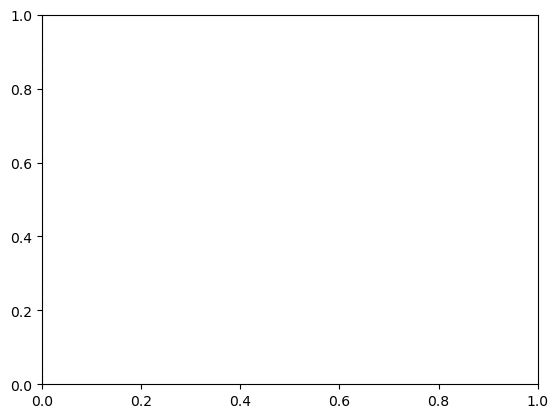

In [21]:
plt.figure()
#plt.axhline(color="0.5", linestyle="--")
plt.axvline(color="0.5", linestyle="--")
line1 = plt.plot(fd1, ek1, 'ko-', label = "$x=30$ nm")
line2 = plt.plot(fd2, ek2, 'o-')
plt.xlabel('H (mT)',fontsize=20)
plt.ylabel('Anisotropy energy ($J$)', fontsize=20)
plt.legend(loc=9, prop={'size': 12})
#plt.legend(loc=8, prop={'size': 13, 'weight': 'bold'})
plt.grid(True)
plt.savefig('Ek_t12.56nm_L50nm_5ns.png.png')
plt.show()

NameError: name 'fd1' is not defined

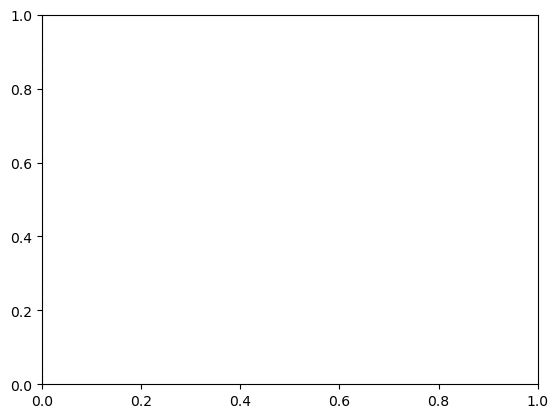

In [22]:
plt.figure()
#plt.axhline(color="0.5", linestyle="--")
plt.axvline(color="0.5", linestyle="--")
line1 = plt.plot(fd1, ez1, 'ko-', label = "$x=30$ nm")
line2 = plt.plot(fd2, ez2, 'o-')
plt.xlabel('H (mT)', fontsize=20 )
plt.ylabel('Zeeman energy ($J$)',fontsize=20 )
plt.legend(loc=9,  prop={'size': 12})
plt.grid(True)
plt.savefig('Ez_t12.56nm_L50nm_5ns.png')
#plt.xlim((-100,100))

plt.show()

NameError: name 'fd1' is not defined

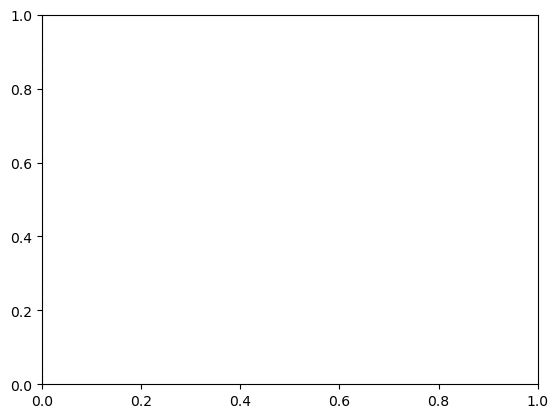

In [23]:
plt.figure()
#plt.axhline(color="0.5", linestyle="--")
plt.axvline(color="0.5", linestyle="--")
line1 = plt.plot(fd1, ed1, 'ko-', label = "$x=30$ nm")
line2 = plt.plot(fd2, ed2, 'o-')
plt.xlabel('H (mT)', fontsize=20)
plt.ylabel('Demagnetizing energy ($ J $)', fontsize=20)
plt.legend(loc=9,prop={'size': 12})
plt.grid(True)
plt.savefig('Ed_t12.56nm_L120nm_5ns.png')
plt.show()

NameError: name 'fd1' is not defined

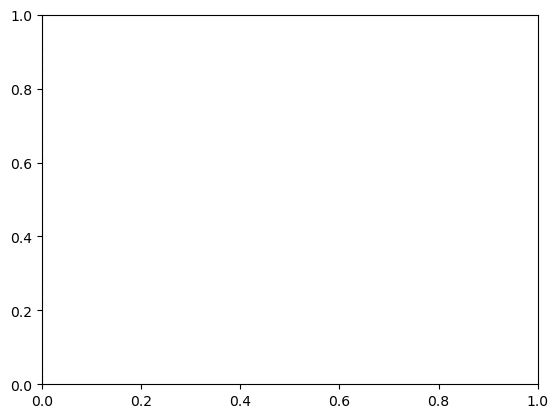

In [24]:
plt.figure()
#plt.axhline(color="0.5", linestyle="--")
plt.axvline(color="0.5", linestyle="--")
line1 = plt.plot(fd1, ex1, 'ko-', label = "$x=30$ nm")
line2 = plt.plot(fd2, ex2, 'o-')
plt.xlabel('H (mT)', fontsize=20)
plt.ylabel('Exchange energy ($J$)', fontsize=20)
plt.legend(loc=8,  prop={'size': 12})
plt.grid(True)
plt.savefig('Ex_t12.56nm_L120nm_5ns.png')
plt.show()

NameError: name 'fd1' is not defined

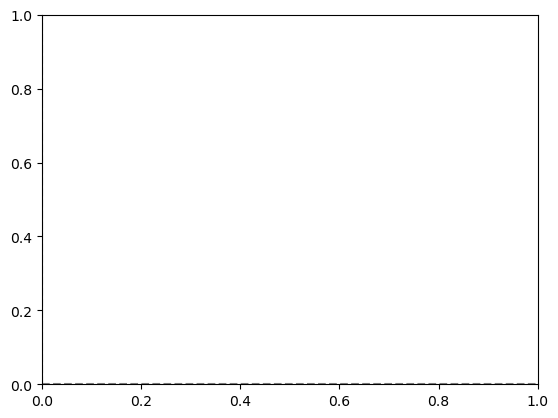

In [25]:
#plt.figure(figsize=(6.5,6))
#plt.title("mio")
plt.axhline(color="0.5", linestyle="--")
plt.axvline(color="0.5", linestyle="--")
line1 = plt.plot(fd1, mg1, 'ko-', label = "$x=30$ nm")
line2 = plt.plot(fd2, mg2, 'o-')
plt.xlabel('H (mT)', fontsize=20)
plt.ylabel('$M/M_s$', fontsize=20)
plt.legend(loc=0,  prop={'size': 12})
#plt.xtics(fontsize=14)
#plt.ytics(fontsize=14)
plt.grid(True, color="0.7")
plt.savefig('hysteresis_t12.56nm_L120nm_5ns.png',bbox_inches="tight", dpi=100)
#plt.xlim((-220,220))
plt.show()

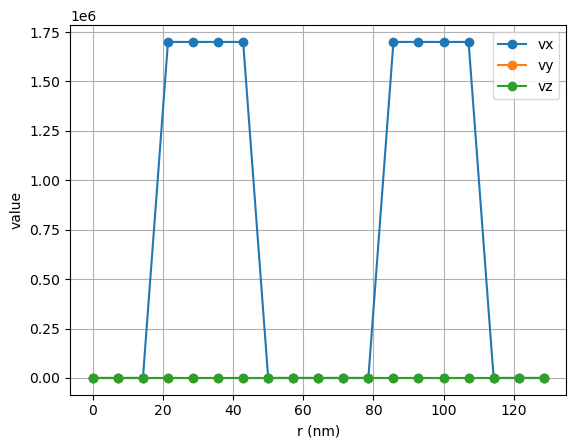

In [26]:
line = system.m.line(p1=system.m.mesh.region.pmin, p2=system.m.mesh.region.pmax, n=19)
line.mpl(marker='o')

NameError: name 'fd1' is not defined

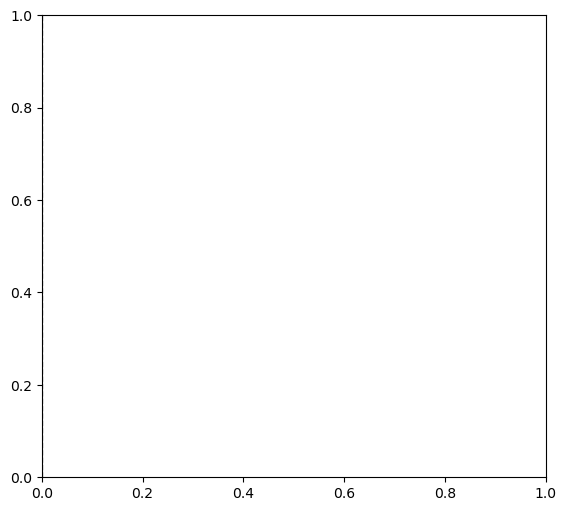

In [27]:
plt.figure(figsize=(6.5,6))
#plt.axhline(color='0.5', linestyle='--', linewidth=1)
plt.axvline(color='0.5', linestyle='--', linewidth=1)
line1 = plt.plot(fd1, tp1, 'ko-', label = '$x = 30$ nm')
line2 = plt.plot(fd2, tp2, 'o-', color='tab:blue')
plt.xlabel('H (mT)', fontsize=20)
plt.ylabel('Topological charge', fontsize=20)
plt.legend(loc=3,  prop={'size': 12})
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.grid(True, color='0.7')
#plt.xlim((-150,150))
#plt.ylim((-1,1))
plt.savefig('Tp_t16nm_D120nm_5ns.png', bbox_inches='tight', dpi=100)
plt.show()

NameError: name 'fd1' is not defined

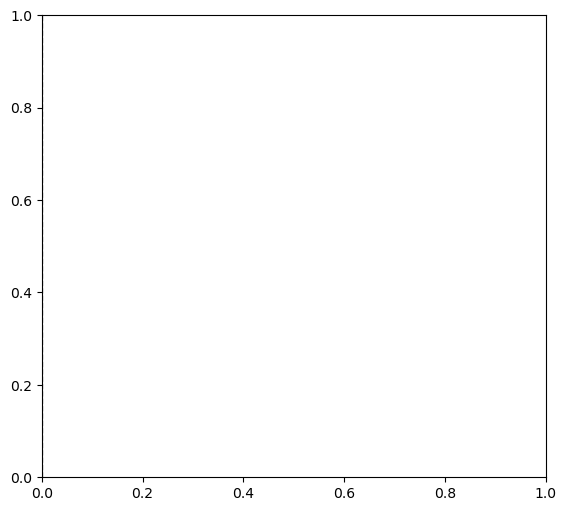

In [28]:
plt.figure(figsize=(6.5,6))
#plt.axhline(color='0.5', linestyle='--', linewidth=1)
plt.axvline(color='0.5', linestyle='--', linewidth=1)
line1 = plt.plot(fd1, tp1, 'ko-', label = '$x = 30$ nm')
line2 = plt.plot(fd2, tp2, 'o-', color='tab:blue')
plt.xlabel('H (mT)', fontsize=20)
plt.ylabel('Topological charge', fontsize=20)
plt.legend(loc=3)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.grid(True, color='0.7')
plt.xlim((-250,250))
#plt.ylim((-1,1))
plt.savefig('Tp_t120nm_D40nm_5ns.png', bbox_inches='tight', dpi=100)
plt.show()

In [29]:
system.table.units

AttributeError: 'System' object has no attribute 'table'

In [30]:
import micromagneticdata as md
data = md.Data(name=system.name)

In [31]:
data.info

,drive_number,date,time,driver,adapter,n_threads,t,n
0,0,2025-04-11,13:14:05,MinDriver,oommfc,None,NaN,NaN
1,1,2025-04-11,13:15:50,MinDriver,oommfc,None,NaN,NaN
2,2,2025-04-11,13:16:06,TimeDriver,oommfc,None,5.000000e-09,10.0
3,3,2025-04-11,13:16:11,TimeDriver,oommfc,None,5.000000e-09,10.0
4,4,2025-04-11,13:16:24,TimeDriver,oommfc,None,5.000000e-09,10.0
5,5,2025-04-11,13:16:28,TimeDriver,oommfc,None,5.000000e-09,10.0
6,6,2025-04-11,13:23:47,MinDriver,oommfc,None,NaN,NaN
7,7,2025-04-11,13:23:58,TimeDriver,oommfc,None,5.000000e-09,10.0
8,8,2025-04-11,13:23:59,TimeDriver,oommfc,None,5.000000e-09,10.0
9,9,2025-04-11,13:50:29,MinDriver,oommfc,None,NaN,NaN


In [32]:
import pandas as pd
df = pd.DataFrame({'fd1': fd1, 'mg1': mg1, 'fd2': fd2, 'mg2': mg2})

print(df)

NameError: name 'fd1' is not defined

In [33]:
# Combinar los datos de las dos mitades
df = pd.DataFrame({
    'fd': pd.concat([pd.Series(fd1), pd.Series(fd2)], ignore_index=True),
    'mg': pd.concat([pd.Series(mg1), pd.Series(mg2)], ignore_index=True)
})

NameError: name 'fd1' is not defined

In [34]:
# Exportar el DataFrame a un archivo .txt
df.to_csv('ciclo_histeresis.txt', sep='\t', index=False, header=True)
print("Archivo exportado como 'ciclo_histeresis30nm.txt'")

AttributeError: module 'discretisedfield' has no attribute 'to_csv'

In [35]:
import pandas as pd
df = pd.DataFrame({'fd1': fd1, 'ex1': ex1, 'fd2': fd2, 'ex2': ex2})

print(df)

NameError: name 'fd1' is not defined

In [36]:
# Combinar los datos de las dos mitades
df = pd.DataFrame({
    'fd': pd.concat([pd.Series(fd1), pd.Series(fd2)], ignore_index=True),
    'mg': pd.concat([pd.Series(ex1), pd.Series(ex2)], ignore_index=True)
})

NameError: name 'fd1' is not defined

In [37]:
# Exportar el DataFrame a un archivo .txt
df.to_csv('energía de intercambio.txt', sep='\t', index=False, header=True)
print("Archivo exportado como 'energía de intercambio30nm.txt'")
import os
print(os.getcwd())  # Imprime el directorio actual

AttributeError: module 'discretisedfield' has no attribute 'to_csv'

In [38]:
df = pd.DataFrame({'fd1': fd1, 'ez1': ez1, 'fd2': fd2, 'ez2': ez2})

print(df)

NameError: name 'fd1' is not defined

In [39]:
# Combinar los datos de las dos mitades
df = pd.DataFrame({
    'fd': pd.concat([pd.Series(fd1), pd.Series(fd2)], ignore_index=True),
    'mg': pd.concat([pd.Series(ez1), pd.Series(ez2)], ignore_index=True)
})

NameError: name 'fd1' is not defined

In [40]:
# Exportar el DataFrame a un archivo .txt
df.to_csv('energía Zeeman.txt', sep='\t', index=False, header=True)
print("Archivo exportado como 'energía Zeeman30nm.txt'")
import os
print(os.getcwd())  # Imprime el directorio actual

AttributeError: module 'discretisedfield' has no attribute 'to_csv'

In [41]:
df = pd.DataFrame({'fd1': fd1, 'ek1': ek1, 'fd2': fd2, 'ek2': ek2})

print(df)

NameError: name 'fd1' is not defined

In [42]:
# Combinar los datos de las dos mitades
df = pd.DataFrame({
    'fd': pd.concat([pd.Series(fd1), pd.Series(fd2)], ignore_index=True),
    'mg': pd.concat([pd.Series(ek1), pd.Series(ek2)], ignore_index=True)
})

NameError: name 'fd1' is not defined

In [43]:
# Exportar el DataFrame a un archivo .txt
df.to_csv('energía de anisotropía.txt', sep='\t', index=False, header=True)
print("Archivo exportado como 'energía de anisotropía30nm.txt'")
import os
print(os.getcwd())  # Imprime el directorio actual

AttributeError: module 'discretisedfield' has no attribute 'to_csv'

In [44]:
df = pd.DataFrame({'fd1': fd1, 'ed1': ed1, 'fd2': fd2, 'ed2': ed2})

print(df)

NameError: name 'fd1' is not defined

In [45]:
# Combinar los datos de las dos mitades
df = pd.DataFrame({
    'fd': pd.concat([pd.Series(fd1), pd.Series(fd2)], ignore_index=True),
    'mg': pd.concat([pd.Series(ed1), pd.Series(ed2)], ignore_index=True)
})

NameError: name 'fd1' is not defined

In [46]:
# Exportar el DataFrame a un archivo .txt
df.to_csv('energía dipolar.txt', sep='\t', index=False, header=True)
print("Archivo exportado como 'energía dipolar30nm.txt'")
import os
print(os.getcwd())  # Imprime el directorio actual

AttributeError: module 'discretisedfield' has no attribute 'to_csv'

In [47]:
import os
print(os.getcwd())  # Imprime el directorio actual

C:\Users\estan\Downloads


In [48]:
df = pd.DataFrame({'fd1': fd1, 'tp1': tp1, 'fd2': fd2, 'tp2': tp2})

print(df)

NameError: name 'fd1' is not defined

In [49]:
# Combinar los datos de las dos mitades
df = pd.DataFrame({
    'fd': pd.concat([pd.Series(fd1), pd.Series(fd2)], ignore_index=True),
    'mg': pd.concat([pd.Series(tp1), pd.Series(tp2)], ignore_index=True)
})

NameError: name 'fd1' is not defined

In [50]:
# Exportar el DataFrame a un archivo .txt
df.to_csv('carga topológica.txt', sep='\t', index=False, header=True)
print("Archivo exportado como 'carga topológica30nm.txt'")
import os
print(os.getcwd())  # Imprime el directorio actual

AttributeError: module 'discretisedfield' has no attribute 'to_csv'